## 1. What this notebook computes

Some differential equations have conditions at BOTH ends of an interval, and they
have solutions only for special values of a number in the equation, the
*eigenvalues*. The **shooting method** finds them: guess the number, solve the
equation from one end as an initial-value problem, see how badly the condition
at the other end fails, and correct the guess. This notebook

- Part A: shoots the equation of a string fixed at both ends,
  $u'' = -\lambda u$ with $u(0) = u(1) = 0$, whose eigenvalues are exactly
  $\lambda_n = n^2 \pi^2$; it finds $\lambda_1 = \pi^2$ by bisection and by the
  secant rule and compares how fast the two converge;
- Part B: shoots the Schroedinger equation of a particle in a finite square
  well (depth $V_0 = 15$, half-width $a = 1$), finds its four bound states with
  RK4 and the even and odd conditions at the centre, and compares every energy
  with the exact solution of the well's transcendental equations, computed with
  mpmath to 30 digits;
- draws the trial solutions that miss and the ones that hit, the shooting
  functions, the bound-state wave functions in the well, and the convergence of
  the computed energies (order 4, as for RK4 itself);
- checks the number of nodes and the orthogonality of the wave functions.

It draws 8 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 02b (The shooting method: a vibrating string and a quantum well) is the file
`Revision/textbook/notebooks/02b_shooting_quantum_well.ipynb` of the repository
Dirac_claude. It finds the eigenvalues of two boundary-value problems by shooting: the
string fixed at both ends, whose eigenvalues are n squared times pi squared, with
bisection and the secant rule, and the finite square well of quantum mechanics (depth 15,
half-width 1, in units with hbar = m = 1), whose four bound states it computes with RK4
and the even and odd conditions at the centre; it compares every energy with the exact
transcendental equations solved with mpmath to 30 digits, counts the nodes of the
eigenfunctions, checks their orthogonality, and measures the order 4 of the eigenvalue
error. It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, mpmath
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 02b_shooting_quantum_well.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 02b_shooting_quantum_well.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
02b_shooting_quantum_well.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/02b.captions.json`
- `Revision/textbook/figures/02b_1_trial_solutions_string.png`
- `Revision/textbook/figures/02b_2_shooting_function_string.png`
- `Revision/textbook/figures/02b_3_bisection_vs_secant.png`
- `Revision/textbook/figures/02b_4_graphical_solution.png`
- `Revision/textbook/figures/02b_5_shooting_functions_well.png`
- `Revision/textbook/figures/02b_6_trial_solutions_well.png`
- `Revision/textbook/figures/02b_7_eigenfunctions.png`
- `Revision/textbook/figures/02b_8_eigenvalue_convergence.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 8 figure files of notebook 02b exist
    ALL 16 CHECKS PASSED (notebook 02b)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/02b_shooting_quantum_well.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "Jupyter command `jupyter-nbconvert` not found" after typing `python -m jupyter
  nbconvert` (the folder that holds the Jupyter programs is not on the search path of the
  computer): start the two programs as Python modules instead. With the environment
  active, in the folder Revision/textbook/notebooks, type the first line below to run the
  notebook headless, or the second line to open it in JupyterLab

      python -m nbconvert --execute --inplace 02b_shooting_quantum_well.ipynb
      python -m jupyterlab 02b_shooting_quantum_well.ipynb

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 02b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 02b (The shooting method: a vibrating string and a quantum well) is the file
# Revision/textbook/notebooks/02b_shooting_quantum_well.ipynb of the repository
# Dirac_claude. It finds the eigenvalues of two boundary-value problems by shooting: the
# string fixed at both ends, whose eigenvalues are n squared times pi squared, with
# bisection and the secant rule, and the finite square well of quantum mechanics (depth
# 15, half-width 1, in units with hbar = m = 1), whose four bound states it computes with
# RK4 and the even and odd conditions at the centre; it compares every energy with the
# exact transcendental equations solved with mpmath to 30 digits, counts the nodes of the
# eigenfunctions, checks their orthogonality, and measures the order 4 of the eigenvalue
# error. It needs a computer with Windows 11, macOS or Linux, an internet connection for
# the installation, the program Git, and Python 3.12 or newer (the notebooks were built
# with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, mpmath
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 02b_shooting_quantum_well.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 02b_shooting_quantum_well.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 02b_shooting_quantum_well.ipynb (in the same folder, without running the cells again)
# to read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/02b.captions.json
# - Revision/textbook/figures/02b_1_trial_solutions_string.png
# - Revision/textbook/figures/02b_2_shooting_function_string.png
# - Revision/textbook/figures/02b_3_bisection_vs_secant.png
# - Revision/textbook/figures/02b_4_graphical_solution.png
# - Revision/textbook/figures/02b_5_shooting_functions_well.png
# - Revision/textbook/figures/02b_6_trial_solutions_well.png
# - Revision/textbook/figures/02b_7_eigenfunctions.png
# - Revision/textbook/figures/02b_8_eigenvalue_convergence.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 8 figure files of notebook 02b exist
#     ALL 16 CHECKS PASSED (notebook 02b)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/02b_shooting_quantum_well.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "Jupyter command jupyter-nbconvert not found" after typing python -m jupyter
#   nbconvert (the folder that holds the Jupyter programs is not on the search path of
#   the computer): start the two programs as Python modules instead. With the environment
#   active, in the folder Revision/textbook/notebooks, type the first line below to run
#   the notebook headless, or the second line to open it in JupyterLab
#     python -m nbconvert --execute --inplace 02b_shooting_quantum_well.ipynb
#     python -m jupyterlab 02b_shooting_quantum_well.ipynb
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "02b"  # this notebook: chapter 02, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 02b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Boundary-value problem**: a differential equation with conditions at two
  different points (here at both ends of an interval), instead of all conditions
  at the start.
- **Eigenvalue, eigenfunction**: a value of the number $\lambda$ (or the energy
  $E$) for which the boundary-value problem has a solution that is not zero
  everywhere; that solution is an eigenfunction.
- **Shooting**: solve from one end with the conditions there and a guessed
  eigenvalue (like aiming a cannon), measure the *mismatch* at the other end
  (where the shot lands), and change the guess until the mismatch is zero.
- **Shooting function** $F$: the mismatch as a function of the guess; the
  eigenvalues are its zeros.
- **Bracket**: two guesses at which $F$ has opposite signs; a continuous $F$ has
  a zero between them.
- **Bisection**: replace the bracket by the half in which the sign changes; the
  bracket halves at every step.
- **Secant rule**: draw the straight line through the last two points
  $(\lambda, F(\lambda))$ and take its zero as the next guess.
- **Schroedinger equation**: the equation of quantum mechanics that gives the
  allowed energies $E$ of a particle in a potential $V(x)$; here, for one
  dimension and in units with $\hbar = m = 1$ ($\hbar$ is Planck's constant
  divided by $2\pi$, $m$ the mass), $-\frac{1}{2} u''(x) + V(x) u(x) = E u(x)$.
  We take it as given.
- **Potential well, bound state**: a region where $V$ is lower than outside; a
  bound state is a solution with $E$ below the outside value of $V$ that decays
  to zero far away. Its energy is an eigenvalue.
- **Wave function** $u(x)$: the eigenfunction of the Schroedinger equation;
  $u(x)^2$ is the probability density of finding the particle at $x$, so we
  *normalise* it: $\int u^2\,dx = 1$.
- **Even, odd (parity)**: $u$ is even if $u(-x) = u(x)$, odd if $u(-x) = -u(x)$.
  An even smooth function has $u'(0) = 0$, an odd one $u(0) = 0$.
- **Node**: a point where the eigenfunction changes sign.
- **Orthogonal**: two functions with $\int u_m u_n\,dx = 0$.

## 4. The physical and mathematical situation

**Part A: the string.** $u'' = -\lambda u$ on $0 \le x \le 1$ with $u(0) = 0$ and
$u(1) = 0$. For $\lambda > 0$ the solutions of the equation are
$A \sin(\sqrt{\lambda}\, x) + B \cos(\sqrt{\lambda}\, x)$ (differentiate twice:
each term comes back multiplied by $-\lambda$). The condition $u(0) = 0$ gives
$B = 0$. We may choose $A$ freely (a multiple of a solution is a solution), so
we start with $u(0) = 0$ and slope $u'(0) = 1$, which gives
$A = 1/\sqrt{\lambda}$:

$$u(x; \lambda) = \frac{\sin(\sqrt{\lambda}\, x)}{\sqrt{\lambda}}, \qquad
F(\lambda) = u(1; \lambda) = \frac{\sin\sqrt{\lambda}}{\sqrt{\lambda}}.$$

$F(\lambda) = 0$ when $\sqrt{\lambda} = n\pi$, that is $\lambda_n = n^2\pi^2$
for $n = 1, 2, 3, \dots$ The same equation describes a particle in a box with
infinitely high walls, with the energy $E = \lambda/2$ (units $\hbar = m = 1$).
The computer does not know the formula: it computes $F(\lambda)$ by solving the
initial-value problem with RK4, and we use the formula only to check it.

**Part B: the finite square well.** The potential is $V(x) = -V_0$ for
$|x| < a$ and $V(x) = 0$ for $|x| > a$, with $V_0 = 15$ and $a = 1$. The
Schroedinger equation $-\frac{1}{2} u'' + V u = E u$ multiplied by $-2$ reads

$$u'' = 2\,(V(x) - E)\, u .$$

A bound state has $-V_0 < E < 0$. Write $k = \sqrt{2(E + V_0)}$ and
$\kappa = \sqrt{-2E}$ (both positive).

- Outside the well ($V = 0$): $u'' = \kappa^2 u$, solved by $e^{\kappa x}$ and
  $e^{-\kappa x}$. For $x < -a$ only $e^{\kappa x}$ goes to zero as
  $x \to -\infty$. So we know exactly how to start: at $x = -a$ take $u = 1$
  and $u' = \kappa$ (the values of $e^{\kappa (x + a)}$ there).
- Inside ($V = -V_0$): $u'' = -k^2 u$, solved by $\cos$ and $\sin$ of $k x$.
- The well is symmetric, so every bound state is even or odd. An even state has
  $u'(0) = 0$, an odd state $u(0) = 0$. These are the conditions at the far end
  of the shot: we integrate from $x = -a$ to $x = 0$ and use the shooting
  functions $F_{\rm even}(E) = u'(0)$ and $F_{\rm odd}(E) = u(0)$.

**The exact answer.** Inside, the solution that starts with $u(-a) = 1$,
$u'(-a) = \kappa$ is $u = \cos(k(x + a)) + (\kappa/k) \sin(k(x + a))$ (check
the two start values by putting $x = -a$). At $x = 0$:
$F_{\rm even} = -k \sin(ka) + \kappa \cos(ka)$, which vanishes when
$k \tan(ka) = \kappa$, and $F_{\rm odd} = \cos(ka) + (\kappa/k) \sin(ka)$, which
vanishes when $-k \cot(ka) = \kappa$. With $z = ka$ and
$z_0 = a\sqrt{2V_0} = \sqrt{30}$ we have $\kappa a = \sqrt{z_0^2 - z^2}$, so

$$\text{even: } \tan z = \frac{\sqrt{z_0^2 - z^2}}{z}, \qquad
\text{odd: } -\cot z = \frac{\sqrt{z_0^2 - z^2}}{z}, \qquad
E = \frac{z^2}{2a^2} - V_0 .$$

These equations have no formula for $z$, but mpmath solves them to any number
of digits. The well has one bound state for each interval of length $\pi/2$
that begins below $z_0$. The intervals begin at $0$, $\pi/2 = 1.571$,
$\pi = 3.142$, $3\pi/2 = 4.712$, $2\pi = 6.283$, ...; with $z_0 = 5.477$
(so $z_0/(\pi/2) = 3.49$) the first four begin below $z_0$ and the fifth does
not, so the well has 4 bound states.

**The connection to this book.** The Kohn-Sham equations of the book are solved
in the same way: two first-order equations in the hidden coordinate are shot
from the tip of the interval to the brane, where (with the ASSUMED mirror
symmetry) an even or an odd condition must hold, exactly like $u'(0) = 0$ or
$u(0) = 0$ here.

## 5. The tools: RK4 for a system, bisection and the secant rule

The next cell defines one RK4 step for a system $Y' = f(x, Y)$ (the same rule
as for one equation, applied to the vector $Y = (u, u')$), the bisection and
the secant rule. Both root finders print nothing; they return the list of all
the guesses they made, so that we can study how fast they approach the root.

In [2]:
import math  # sqrt, sin, pi for single numbers

import mpmath  # numbers with as many digits as we ask for
import numpy as np  # arrays (vectors) of numbers

# Colours that colour-blind readers can tell apart; curves also differ by style.
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
GREY, BLACK = "#8a8986", "#000000"
LEVEL_COLORS = [BLUE, ORANGE, AQUA, VIOLET]  # one colour per bound state


def rk4_step(f, x, Y, h):
    """One classical RK4 step for the system Y' = f(x, Y)."""
    k1 = f(x, Y)
    k2 = f(x + h / 2, Y + (h / 2) * k1)
    k3 = f(x + h / 2, Y + (h / 2) * k2)
    k4 = f(x + h, Y + h * k3)
    return Y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def bisection(F, lo, hi, steps):
    """steps bisection steps on the bracket (lo, hi); the list of midpoints."""
    f_lo = F(lo)
    guesses = []
    for _ in range(steps):
        mid = 0.5 * (lo + hi)
        f_mid = F(mid)
        guesses.append(mid)
        if (f_mid > 0) == (f_lo > 0):  # same sign as at lo: the root is right
            lo, f_lo = mid, f_mid
        else:  # opposite sign: the root lies between lo and mid
            hi = mid
    return guesses


def secant(F, x0, x1, steps):
    """steps secant steps from the guesses x0, x1; the list of new guesses."""
    f0, f1 = F(x0), F(x1)
    guesses = []
    for _ in range(steps):
        if f1 == f0:  # the line is flat: no new information (converged)
            break
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)  # the zero of the line
        x0, f0, x1, f1 = x1, f1, x2, F(x2)
        guesses.append(x2)
    return guesses


say("RK4 for systems, bisection and the secant rule are defined.")

RK4 for systems, bisection and the secant rule are defined.


## 6. Part A: shooting the string

The function `shoot_string(lam, n)` solves $u'' = -\lambda u$ as the system
$u' = v$, $v' = -\lambda u$ from $x = 0$ with $u = 0$, $v = 1$, in $n$ RK4 steps,
and returns all the points. The first cell draws three shots: with
$\lambda = 5$ the string comes down too late, with $\lambda = 15$ too early, and
with $\lambda = \pi^2$ it lands exactly at $u(1) = 0$.

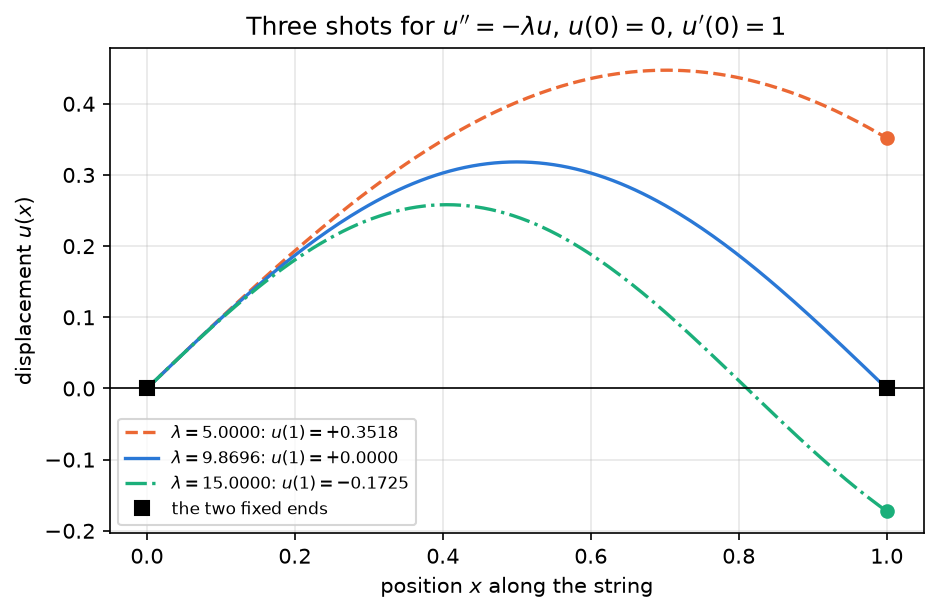

Figure 02b.1 saved as Revision/textbook/figures/02b_1_trial_solutions_string.png
PASS u(1) > 0 for lambda = 5, < 0 for lambda = 15, = 0 for lambda = pi^2


In [3]:
def shoot_string(lam, n):
    """RK4 solution of u'' = -lam u, u(0) = 0, u'(0) = 1 on 0 <= x <= 1 in n
    steps.  Returns the n + 1 positions and the n + 1 values of u."""
    def f(x, Y):
        return np.array([Y[1], -lam * Y[0]])  # (u', v') = (v, -lam u)
    h = 1.0 / n
    Y = np.array([0.0, 1.0])  # u(0) = 0, u'(0) = 1
    xs, us = [0.0], [0.0]
    for i in range(n):
        Y = rk4_step(f, i * h, Y, h)
        xs.append((i + 1) * h)
        us.append(Y[0])
    return np.array(xs), np.array(us)


def F_string(lam, n=200):
    """The shooting function: where the shot lands, u(1)."""
    return shoot_string(lam, n)[1][-1]


fig, ax = plt.subplots()
for lam, color, style in ((5.0, ORANGE, "--"), (math.pi ** 2, BLUE, "-"),
                          (15.0, AQUA, "-.")):
    xs, us = shoot_string(lam, 200)
    ax.plot(xs, us, style, color=color, lw=1.6,
            label=f"$\\lambda = {lam:.4f}$: $u(1) = {us[-1]:+.4f}$")
    ax.plot([1.0], [us[-1]], "o", color=color, ms=6)
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.plot([0.0, 1.0], [0.0, 0.0], "s", color=BLACK, ms=7, label="the two fixed ends")
ax.set_xlabel("position $x$ along the string")
ax.set_ylabel("displacement $u(x)$")
ax.set_title("Three shots for $u'' = -\\lambda u$, $u(0) = 0$, $u'(0) = 1$")
ax.legend(fontsize=8)
save_figure(fig, "trial_solutions_string",
            "Three shots for the string equation $d^2u/dx^2 = -\\lambda u$ started at "
            "$x = 0$ with $u = 0$ and slope 1, computed with RK4 (200 steps). "
            "Horizontal axis the position $x$ from 0 to 1, vertical axis the "
            "displacement $u$ (arbitrary units). The target is $u(1) = 0$ (black "
            "squares: the fixed ends). With $\\lambda = 5$ the shot lands above "
            "the target, with $\\lambda = 15$ below it, and with "
            "$\\lambda = \\pi^2 = 9.8696$ exactly on it: $\\pi^2$ is an "
            "eigenvalue.")
check(F_string(5.0) > 0 > F_string(15.0) and abs(F_string(math.pi ** 2)) < 1e-9,
      "u(1) > 0 for lambda = 5, < 0 for lambda = 15, = 0 for lambda = pi^2")

The next cell draws the whole shooting function $F(\lambda) = u(1; \lambda)$ for
$\lambda$ from 0.5 to 100: the RK4 values (points) and the exact
$\sin\sqrt{\lambda}/\sqrt{\lambda}$ (line). Its zeros are the eigenvalues
$\pi^2$, $4\pi^2$ and $9\pi^2$.

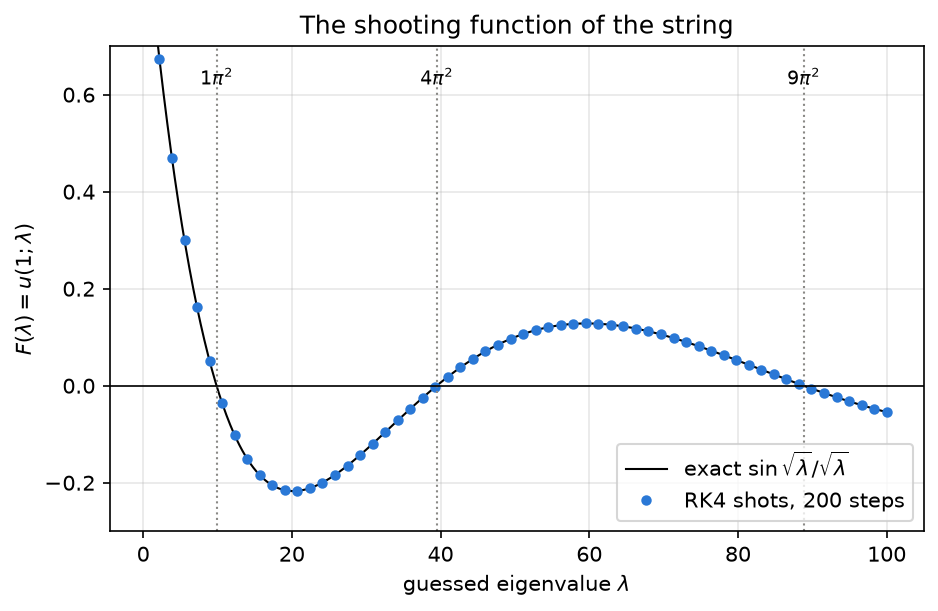

Figure 02b.2 saved as Revision/textbook/figures/02b_2_shooting_function_string.png
RESULT largest difference RK4 - exact shooting function = 4.54e-08
PASS the RK4 shooting function equals sin(sqrt(lam))/sqrt(lam)


In [4]:
lam_points = np.linspace(0.5, 100.0, 60)  # 60 guesses for RK4
lam_fine = np.linspace(0.5, 100.0, 800)  # many points for the exact curve
F_points = np.array([F_string(lam) for lam in lam_points])
F_exact = np.sin(np.sqrt(lam_fine)) / np.sqrt(lam_fine)
fig, ax = plt.subplots()
ax.plot(lam_fine, F_exact, color=BLACK, lw=1.0,
        label="exact $\\sin\\sqrt{\\lambda}/\\sqrt{\\lambda}$")
ax.plot(lam_points, F_points, "o", color=BLUE, ms=4, label="RK4 shots, 200 steps")
for n in (1, 2, 3):
    ax.axvline(n ** 2 * math.pi ** 2, ls=":", color=GREY, lw=1.0)
    ax.text(n ** 2 * math.pi ** 2, 0.62, f"${n * n}\\pi^2$", ha="center",
            fontsize=9)
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.set_xlabel("guessed eigenvalue $\\lambda$")
ax.set_ylabel("$F(\\lambda) = u(1; \\lambda)$")
ax.set_ylim(-0.3, 0.7)
ax.set_title("The shooting function of the string")
ax.legend()
save_figure(fig, "shooting_function_string",
            "The shooting function $F(\\lambda) = u(1; \\lambda)$ of the string, "
            "for $\\lambda$ from 0.5 to 100 (both axes pure numbers): the "
            "values computed by RK4 with 200 steps (blue points) and the exact "
            "$\\sin\\sqrt{\\lambda}/\\sqrt{\\lambda}$ (black line). The zeros, "
            "marked by dotted lines, are the eigenvalues $\\pi^2 = 9.87$, "
            "$4\\pi^2 = 39.48$ and $9\\pi^2 = 88.83$; between two zeros $F$ "
            "keeps its sign, so every pair of guesses with opposite signs of $F$ "
            "brackets an eigenvalue.")
worst = np.max(np.abs(F_points - np.sin(np.sqrt(lam_points)) /
                      np.sqrt(lam_points)))
report("largest difference RK4 - exact shooting function", f"{worst:.2e}")
check(worst < 1e-7, "the RK4 shooting function equals sin(sqrt(lam))/sqrt(lam)")

## 7. Bisection against the secant rule

Both start from the bracket $5 < \lambda < 15$ (where $F(5) > 0 > F(15)$). The
next cell prints the first six bisection steps (each one gains one binary digit)
and the first six secant steps (each one roughly multiplies the number of
correct digits by 1.6), then runs both further and draws the error
$|\lambda_k - \pi^2|$ after each step on a logarithmic axis.

step   bisection midpoint   F(midpoint)    secant guess
   1            10.000000      -0.00654      11.7107898
   2             7.500000      +0.14320       8.8043277
   3             8.750000      +0.06170      10.0237185
   4             9.375000      +0.02601       9.8815597
   5             9.687500      +0.00935       9.8694633
   6             9.843750      +0.00131       9.8696045
RESULT eigenvalue by RK4 shooting (200 steps) = 9.869604411103
RESULT pi^2 = 9.869604401089


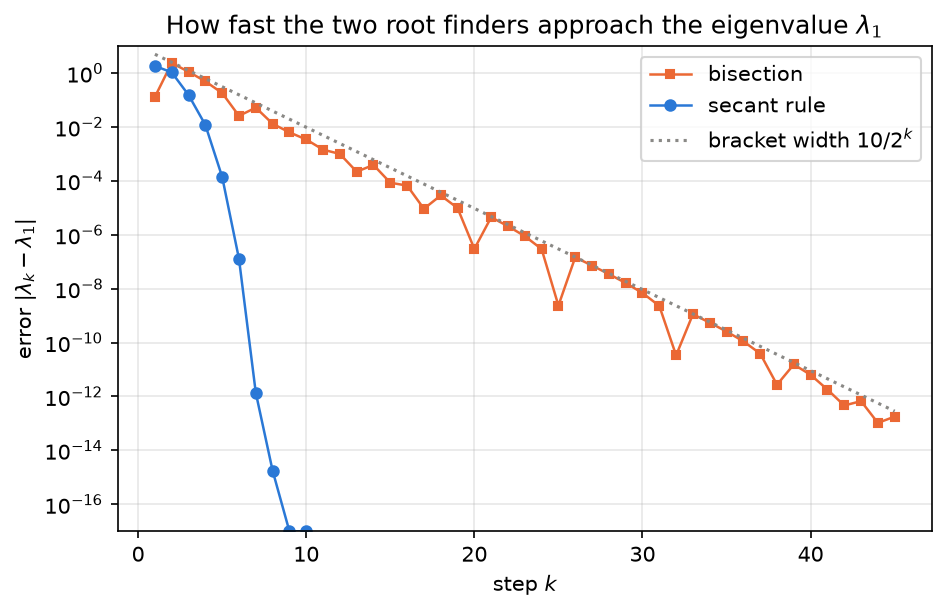

Figure 02b.3 saved as Revision/textbook/figures/02b_3_bisection_vs_secant.png
PASS the bisection midpoints 10, 7.5, 8.75, 9.375, 9.6875, 9.84375
PASS after 6 steps: secant within 1e-6 of pi^2, bisection still 0.02 away
PASS RK4 eigenvalue = pi^2 within 2e-8; 45 bisections agree within 1e-11


In [5]:
PI2 = math.pi ** 2  # the exact eigenvalue
bis = bisection(F_string, 5.0, 15.0, 45)
sec = secant(F_string, 5.0, 15.0, 12)
say("step   bisection midpoint   F(midpoint)    secant guess")
for k in range(6):
    say(f"{k + 1:4d}   {bis[k]:18.6f}   {F_string(bis[k]):+11.5f}   {sec[k]:13.7f}")
lam_rk4 = sec[-1]  # the converged secant value: the RK4 eigenvalue (200 steps)
report("eigenvalue by RK4 shooting (200 steps)", f"{lam_rk4:.12f}")
report("pi^2", f"{PI2:.12f}")
errors_bis = np.abs(np.array(bis) - lam_rk4)
errors_sec = np.abs(np.array(sec) - lam_rk4)
fig, ax = plt.subplots()
ax.semilogy(range(1, len(bis) + 1), np.maximum(errors_bis, 1e-17), "s-",
            color=ORANGE, ms=4, lw=1.2, label="bisection")
ax.semilogy(range(1, len(sec) + 1), np.maximum(errors_sec, 1e-17), "o-",
            color=BLUE, ms=5, lw=1.2, label="secant rule")
k_values = np.arange(1, len(bis) + 1)
ax.semilogy(k_values, 10.0 / 2.0 ** k_values, ":", color=GREY,
            label="bracket width $10/2^k$")
ax.set_xlabel("step $k$")
ax.set_ylabel("error $|\\lambda_k - \\lambda_1|$")
ax.set_ylim(1e-17, 10.0)
ax.set_title("How fast the two root finders approach the eigenvalue $\\lambda_1$")
ax.legend()
save_figure(fig, "bisection_vs_secant",
            "The error of the guess after $k$ steps, $|\\lambda_k - \\lambda_1|$, "
            "where $\\lambda_1$ is the zero of the RK4 shooting function (200 "
            "steps), which differs from $\\pi^2$ by $1.0 \\times 10^{-8}$, "
            "for bisection (squares) and the secant rule (circles), both started "
            "from 5 and 15, on a logarithmic vertical axis (pure numbers); errors "
            "of exactly zero are drawn at $10^{-17}$. Bisection follows the "
            "dotted line of the halving bracket, one binary digit per step, and "
            "after 45 steps it is still about $10^{-13}$ away (the bracket is "
            "$10/2^{45} = 2.8 \\times 10^{-13}$ wide); the secant rule reaches the "
            "rounding level in about 9 steps, its error falling faster and faster.")
check(bis[:6] == [10.0, 7.5, 8.75, 9.375, 9.6875, 9.84375],
      "the bisection midpoints 10, 7.5, 8.75, 9.375, 9.6875, 9.84375")
check(abs(sec[5] - PI2) < 1e-6 and abs(bis[5] - PI2) > 0.02,
      "after 6 steps: secant within 1e-6 of pi^2, bisection still 0.02 away")
check(abs(lam_rk4 - PI2) < 2e-8 and abs(bis[-1] - lam_rk4) < 1e-11,
      "RK4 eigenvalue = pi^2 within 2e-8; 45 bisections agree within 1e-11")

## 8. Part B: the finite square well, solved exactly with mpmath

The next cell solves the even and odd equations of section 4 with mpmath at 30
significant digits. To avoid the infinities of $\tan$ and $\cot$ it multiplies
them out: even $g(z) = z \sin z - \sqrt{z_0^2 - z^2}\cos z = 0$, odd
$g(z) = z \cos z + \sqrt{z_0^2 - z^2}\sin z = 0$. Even roots lie between $n\pi$
and $n\pi + \pi/2$, odd ones between $n\pi + \pi/2$ and $(n + 1)\pi$ (but never
beyond $z_0$); mpmath's `findroot` with the method "anderson" refines each
bracket. The figure shows the classic graphical solution: the curves $\tan z$
and $-\cot z$ cross the curve $\sqrt{z_0^2 - z^2}/z$ at the solutions.

state 0 (even): z = 1.3262301881908503282, E = -14.120556743965630861
state 1 (odd ): z = 2.6388922601494099741, E = -11.518123819661769376
state 2 (even): z = 3.9158583447044145113, E = -7.3330267121044013902
state 3 (odd ): z = 5.0904451651058404757, E = -2.0436840105252862495
PASS the well has 4 bound states: even, odd, even, odd


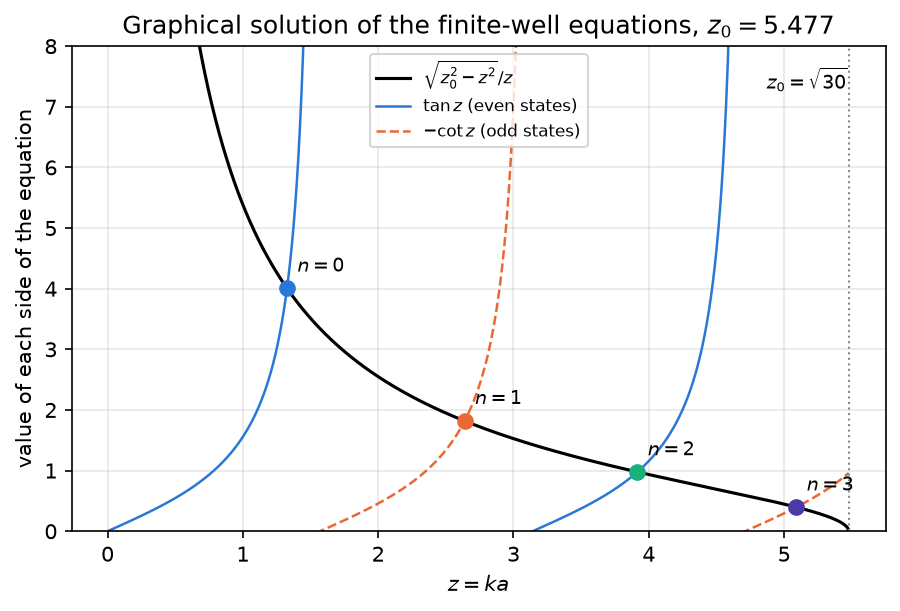

Figure 02b.4 saved as Revision/textbook/figures/02b_4_graphical_solution.png


In [6]:
V0, A = 15.0, 1.0  # the depth and the half-width of the well
mpmath.mp.dps = 30  # work with 30 significant digits
Z0 = mpmath.sqrt(2 * mpmath.mpf(V0)) * A  # z0 = a sqrt(2 V0) = sqrt(30)


def g_even(z):
    return z * mpmath.sin(z) - mpmath.sqrt(Z0 ** 2 - z ** 2) * mpmath.cos(z)


def g_odd(z):
    return z * mpmath.cos(z) + mpmath.sqrt(Z0 ** 2 - z ** 2) * mpmath.sin(z)


EXACT = []  # (energy, parity) of the bound states, lowest first
for j in range(8):  # the intervals of length pi/2 between 0 and z0
    lo = j * mpmath.pi / 2
    hi = min((j + 1) * mpmath.pi / 2, Z0)
    if lo >= Z0:
        break
    g, parity = (g_even, "even") if j % 2 == 0 else (g_odd, "odd")
    # the root inside the interval (lo, hi), searched a hair away from its ends
    z = mpmath.findroot(g, (lo + mpmath.mpf("1e-20"), hi - mpmath.mpf("1e-20")),
                        solver="anderson")
    EXACT.append((z ** 2 / (2 * A ** 2) - V0, parity, z))
for n, (energy, parity, z) in enumerate(EXACT):
    say(f"state {n} ({parity:4}): z = {mpmath.nstr(z, 20)}, "
        f"E = {mpmath.nstr(energy, 20)}")
check(len(EXACT) == 4 and [p for _, p, _ in EXACT] == ["even", "odd", "even", "odd"],
      "the well has 4 bound states: even, odd, even, odd")

z_axis = np.linspace(0.01, float(Z0), 2000)
rhs = np.sqrt(float(Z0) ** 2 - z_axis ** 2) / z_axis
tan_z = np.tan(z_axis)
cot_z = -1.0 / np.tan(z_axis)
tan_z[np.abs(tan_z) > 12] = np.nan  # do not draw the jumps at the poles
cot_z[np.abs(cot_z) > 12] = np.nan
fig, ax = plt.subplots()
ax.plot(z_axis, rhs, color=BLACK, lw=1.5, label="$\\sqrt{z_0^2 - z^2}/z$")
ax.plot(z_axis, tan_z, color=BLUE, lw=1.2, label="$\\tan z$ (even states)")
ax.plot(z_axis, cot_z, "--", color=ORANGE, lw=1.2, label="$-\\cot z$ (odd states)")
for n, (energy, parity, z) in enumerate(EXACT):
    zf = float(z)
    ax.plot([zf], [math.sqrt(float(Z0) ** 2 - zf ** 2) / zf], "o",
            color=LEVEL_COLORS[n], ms=7, zorder=5)
    ax.annotate(f"$n = {n}$", (zf, math.sqrt(float(Z0) ** 2 - zf ** 2) / zf),
                textcoords="offset points", xytext=(5, 8), fontsize=9)
ax.axvline(float(Z0), color=GREY, ls=":", lw=1.0)
ax.text(float(Z0), 7.3, "$z_0 = \\sqrt{30}$", ha="right", fontsize=9)
ax.set_ylim(0.0, 8.0)
ax.set_xlabel("$z = k a$")
ax.set_ylabel("value of each side of the equation")
ax.set_title("Graphical solution of the finite-well equations, $z_0 = 5.477$")
ax.legend(loc="upper center", fontsize=8)
save_figure(fig, "graphical_solution",
            "The graphical solution of the finite-well equations for "
            "$z_0 = a\\sqrt{2V_0} = \\sqrt{30} = 5.477$: horizontal axis "
            "$z = ka$ (a pure number), vertical axis the value of each side. The "
            "black curve is $\\sqrt{z_0^2 - z^2}/z$, the blue branches $\\tan z$ "
            "(even states), the dashed orange branches $-\\cot z$ (odd states). "
            "Each crossing, marked by a dot, is one bound state; there are four, "
            "alternately even and odd, and none beyond $z_0$, where the black "
            "curve reaches zero.")

## 9. Part B by shooting with RK4

The function `shoot_well(E, n)` starts at $x = -a$ with $u = 1$, $u' = \kappa$
and makes $n$ RK4 steps to $x = 0$ with the inside equation $u'' = -2(V_0 + E)
u$. It works for one energy or for a whole array of energies at once (numpy
computes elementwise), which makes the scan of the shooting functions fast. The
next cell draws $F_{\rm even}(E) = u'(0)$ and $F_{\rm odd}(E) = u(0)$ for 400
energies between $-V_0$ and 0 and marks the exact energies.

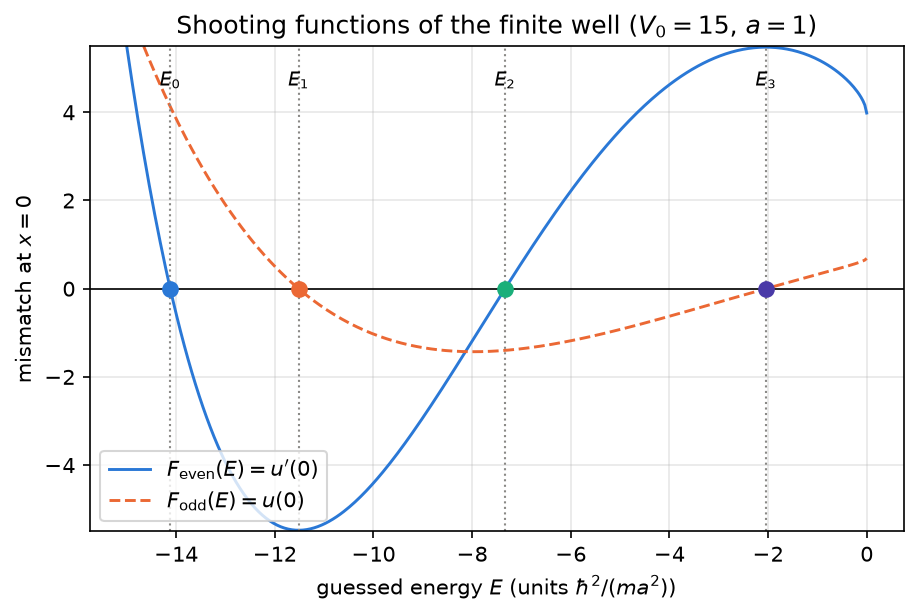

Figure 02b.5 saved as Revision/textbook/figures/02b_5_shooting_functions_well.png
RESULT sign changes of F_even and F_odd in the scan = 2, 2
PASS the scan finds 2 even and 2 odd sign changes, one per bound state


In [7]:
def shoot_well(E, n):
    """RK4 from x = -a (u = 1, u' = kappa) to x = 0 inside the well; E may be an
    array.  Returns (u(0), u'(0))."""
    E = np.asarray(E, dtype=float)
    kappa = np.sqrt(-2.0 * E)  # the decay rate outside the well

    def f(x, Y):
        return np.array([Y[1], 2.0 * (-V0 - E) * Y[0]])  # (u', 2 (V - E) u)
    h = A / n
    Y = np.array([np.ones_like(E), kappa])
    for i in range(n):
        Y = rk4_step(f, -A + i * h, Y, h)
    return Y[0], Y[1]


def F_even(E, n=200):
    return shoot_well(E, n)[1]  # u'(0): zero for an even state


def F_odd(E, n=200):
    return shoot_well(E, n)[0]  # u(0): zero for an odd state


E_scan = np.linspace(-V0 + 1e-3, -1e-3, 400)  # 400 guesses inside (-V0, 0)
fe, fo = F_even(E_scan), F_odd(E_scan)
fig, ax = plt.subplots()
ax.plot(E_scan, fe, color=BLUE, lw=1.4, label="$F_{\\rm even}(E) = u'(0)$")
ax.plot(E_scan, fo, "--", color=ORANGE, lw=1.4, label="$F_{\\rm odd}(E) = u(0)$")
for n, (energy, parity, _) in enumerate(EXACT):
    ax.axvline(float(energy), ls=":", color=GREY, lw=1.0)
    ax.plot([float(energy)], [0.0], "o", color=LEVEL_COLORS[n], ms=7, zorder=5)
    ax.text(float(energy), 4.6, f"$E_{n}$", ha="center", fontsize=9)
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.set_ylim(-5.5, 5.5)
ax.set_xlabel("guessed energy $E$ (units $\\hbar^2/(m a^2)$)")
ax.set_ylabel("mismatch at $x = 0$")
ax.set_title("Shooting functions of the finite well ($V_0 = 15$, $a = 1$)")
ax.legend(loc="lower left")
save_figure(fig, "shooting_functions_well",
            "The shooting functions of the finite well: $F_{\\rm even}(E) = "
            "u'(0)$ (solid blue) and $F_{\\rm odd}(E) = u(0)$ (dashed orange) for "
            "400 guessed energies between $-V_0 = -15$ and $0$ (horizontal axis, "
            "units $\\hbar^2/(m a^2)$; vertical axis the mismatch, arbitrary "
            "units), each computed by shooting with RK4 from $x = -a$, where "
            "$u = 1$ and $u' = \\kappa$. The dots on the axis are the exact "
            "energies from the transcendental equations: the zeros of "
            "$F_{\\rm even}$ give the even states $E_0, E_2$, those of "
            "$F_{\\rm odd}$ the odd states $E_1, E_3$.")
even_changes = int(np.sum(np.sign(fe[:-1]) != np.sign(fe[1:])))
odd_changes = int(np.sum(np.sign(fo[:-1]) != np.sign(fo[1:])))
report("sign changes of F_even and F_odd in the scan", f"{even_changes}, {odd_changes}")
check(even_changes == 2 and odd_changes == 2,
      "the scan finds 2 even and 2 odd sign changes, one per bound state")

The next cell turns every sign change of a scan (made with the same number of
RK4 steps as the refinement) into a bracket and refines all four brackets AT
ONCE by bisection (each step evaluates both shooting functions
for the four midpoints as one numpy array), until the brackets are narrower
than $10^{-13}$. Then it compares the four energies with the 30-digit exact
values.

In [8]:
def well_levels(n, tolerance=1e-13):
    """The four energies with n RK4 steps: scan, then bisection on the brackets."""
    lo, hi, even = [], [], []
    for values, is_even in ((F_even(E_scan, n), True), (F_odd(E_scan, n), False)):
        # the places i where the sign of the mismatch differs from that at i + 1
        for i in np.nonzero(np.sign(values[:-1]) != np.sign(values[1:]))[0]:
            lo.append(E_scan[i])
            hi.append(E_scan[i + 1])
            even.append(is_even)
    order = np.argsort(lo)  # lowest energy first
    lo, hi = np.array(lo)[order], np.array(hi)[order]
    even = np.array(even)[order]

    def mismatch(E):
        u0, du0 = shoot_well(E, n)
        return np.where(even, du0, u0)  # u'(0) for even, u(0) for odd states
    f_lo = mismatch(lo)
    while np.max(hi - lo) > tolerance:
        mid = 0.5 * (lo + hi)
        f_mid = mismatch(mid)
        same = np.sign(f_mid) == np.sign(f_lo)  # the root is above mid
        lo, f_lo = np.where(same, mid, lo), np.where(same, f_mid, f_lo)
        hi = np.where(same, hi, mid)
    return 0.5 * (lo + hi), even


LEVELS, EVEN = well_levels(200)
exact = np.array([float(energy) for energy, _, _ in EXACT])
for n, (E_n, E_x) in enumerate(zip(LEVELS, exact)):
    say(f"E_{n}: RK4 (200 steps) {E_n:.12f}, exact {E_x:.12f}, "
        f"difference {E_n - E_x:+.1e}")
check(np.max(np.abs(LEVELS - exact)) < 1e-7,
      "the four shooting energies agree with the exact ones within 1e-7")
check(list(EVEN) == [True, False, True, False],
      "the levels alternate: even, odd, even, odd")

E_0: RK4 (200 steps) -14.120556743942, exact -14.120556743966, difference +2.4e-11
E_1: RK4 (200 steps) -11.518123818206, exact -11.518123819662, difference +1.5e-09
E_2: RK4 (200 steps) -7.333026697216, exact -7.333026712104, difference +1.5e-08
E_3: RK4 (200 steps) -2.043683949908, exact -2.043684010525, difference +6.1e-08
PASS the four shooting energies agree with the exact ones within 1e-7
PASS the levels alternate: even, odd, even, odd


## 10. What a shot looks like when it misses

For the ground state $E_0$, the next cell shoots across the WHOLE line from
$x = -3$ to $x = +3$ (600 RK4 steps of $h = 0.01$, so that the walls $x = \pm 1$
are grid points and the potential is constant inside every step). It starts
with the exactly decaying solution $u = e^{\kappa(x + a)}$, $u' = \kappa u$ at
$x = -3$. Only at the eigenvalue does the shot come down to zero on the right;
a little below or above $E_0$, the growing solution $e^{\kappa x}$ takes over
and the shot flies off to $+\infty$ or $-\infty$. That is the reason why only
special energies are allowed.

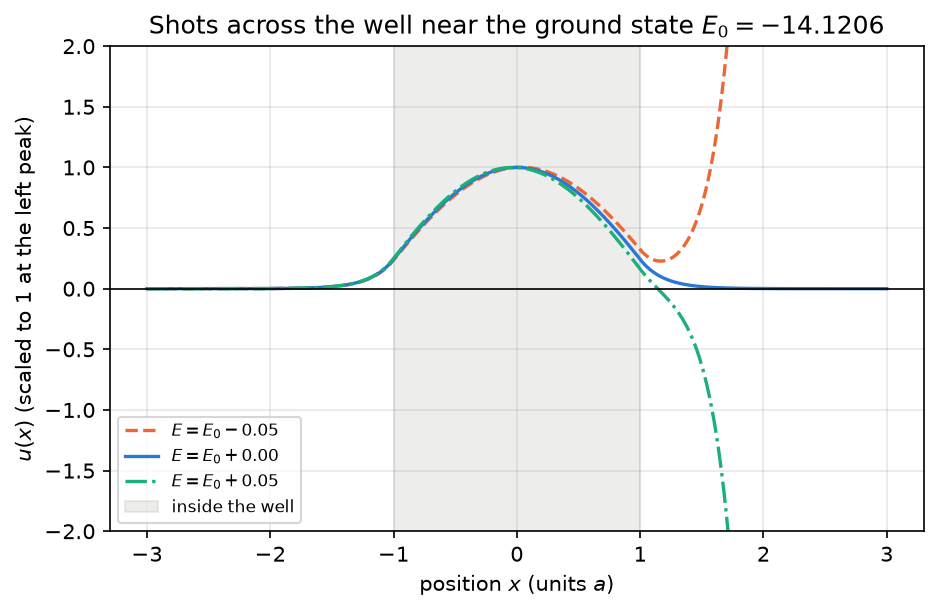

Figure 02b.6 saved as Revision/textbook/figures/02b_6_trial_solutions_well.png
PASS slightly below and above E0 the shots fly off to opposite infinities


In [9]:
def shoot_line(E, x_start=-3.0, x_end=3.0, n=600):
    """RK4 across the whole line; the potential is taken at the middle of every
    step (constant inside a step, because the walls are grid points)."""
    kappa = math.sqrt(-2.0 * E)
    h = (x_end - x_start) / n
    Y = np.array([1.0, kappa]) * math.exp(kappa * (x_start + A))  # exact tail
    xs, us = [x_start], [Y[0]]
    for i in range(n):
        x = x_start + i * h
        V = -V0 if abs(x + h / 2) < A else 0.0  # the potential of this step

        def f(x_value, Y_value, V=V):  # V=V freezes this step's potential in f
            return np.array([Y_value[1], 2.0 * (V - E) * Y_value[0]])
        Y = rk4_step(f, x, Y, h)
        xs.append(x + h)
        us.append(Y[0])
    return np.array(xs), np.array(us)


E0 = float(EXACT[0][0])
fig, ax = plt.subplots()
for shift, color, style in ((-0.05, ORANGE, "--"), (0.0, BLUE, "-"),
                            (0.05, AQUA, "-.")):
    xs, us = shoot_line(E0 + shift)
    ax.plot(xs, us / np.max(np.abs(us[xs <= 0])), style, color=color, lw=1.6,
            label=f"$E = E_0 {shift:+.2f}$")
ax.axvspan(-A, A, color=GREY, alpha=0.15, label="inside the well")
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("position $x$ (units $a$)")
ax.set_ylabel("$u(x)$ (scaled to 1 at the left peak)")
ax.set_title("Shots across the well near the ground state $E_0 = %.4f$" % E0)
ax.legend(loc="lower left", fontsize=8)
save_figure(fig, "trial_solutions_well",
            "Shots across the whole line from $x = -3$ to $x = 3$ (horizontal "
            "axis, units of the half-width $a$; the shaded band is the well) for "
            f"the ground-state energy $E_0 = {E0:.4f}$ and for $E_0 \\pm 0.05$; "
            "vertical axis the solution $u$, scaled to 1 at its largest value "
            "left of the centre (arbitrary units). Every shot starts as the "
            "decaying solution on the left. At $E_0$ (solid blue) it decays on the "
            "right as well: a bound state. Slightly below (dashed orange) or above "
            "(dash-dotted aqua), the growing exponential takes over and the shot "
            "flies off to plus or minus infinity.")
tail = {shift: shoot_line(E0 + shift)[1][-1] for shift in (-0.05, 0.05)}
check(tail[-0.05] * tail[0.05] < 0 and min(abs(tail[-0.05]), abs(tail[0.05])) > 10,
      "slightly below and above E0 the shots fly off to opposite infinities")

## 11. The four wave functions

The next cell builds each normalised wave function on $-3 \le x \le 3$: inside
the left half of the well from the RK4 shot (200 steps), on the right half by
the symmetry $u(-x) = u(x)$ (even) or $u(-x) = -u(x)$ (odd), and outside from
the exact tails $u(-a) e^{\kappa(x + a)}$. The normalisation integral uses
Simpson's rule inside (an integration rule with error $\propto h^4$) and the
exact tail integral $\int_{-\infty}^{-a} e^{2\kappa(x + a)} dx = 1/(2\kappa)$.
It draws each wave function lifted to the height of its energy, inside the
drawing of the potential, counts the nodes, and checks the normalisation and
the orthogonality. For an even and an odd state the product $u_m u_n$ is odd
(it changes sign when $x$ is replaced by $-x$), so the contributions of the
left and the right half cancel and its integral is exactly zero; for two states
of the same parity the cell computes the integral (twice the left half: Simpson
inside, the exact tail $u_m(-a) u_n(-a)/(\kappa_m + \kappa_n)$ outside).
Finally the cell tests the cancellation for the four pairs of different parity
numerically: it integrates $u_m u_n$ with Simpson's rule over the whole drawn
range $-3 \le x \le 3$, and over the left half $-3 \le x \le 0$ alone. The
whole integral must vanish, although the half does not.

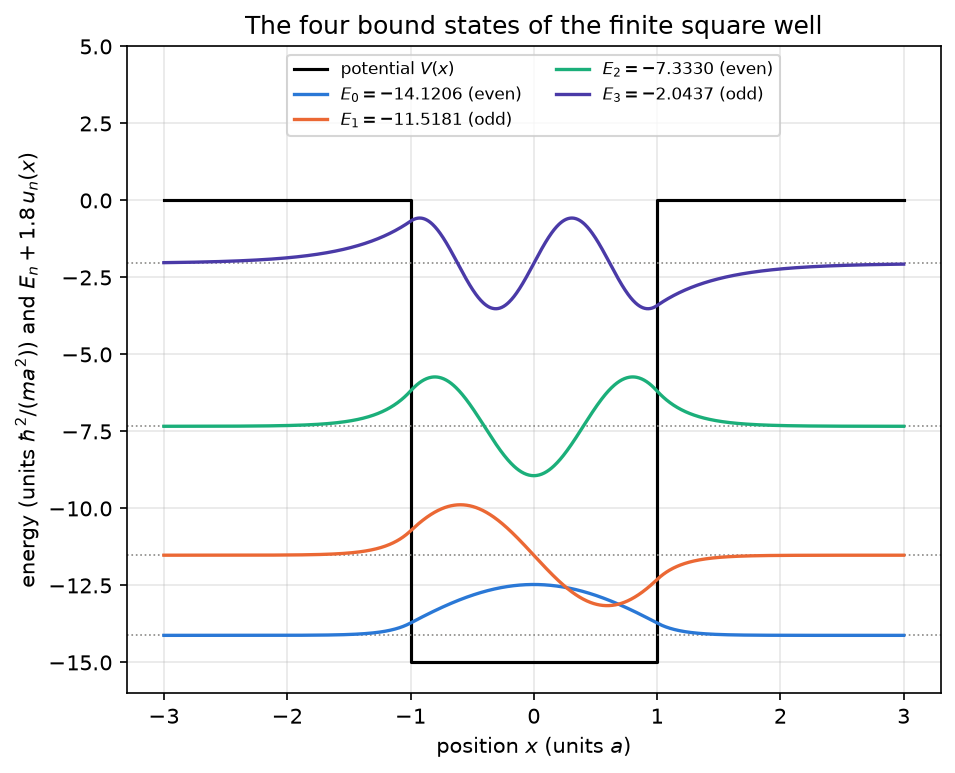

Figure 02b.7 saved as Revision/textbook/figures/02b_7_eigenfunctions.png
RESULT nodes of the states 0 to 3 = [0, 1, 2, 3]
PASS the state n has exactly n nodes
RESULT largest |integral u_m u_n - (1 if m = n else 0)| = 1.6e-10
PASS the wave functions are normalised and orthogonal within 1e-8
RESULT different parity: largest |whole integral|, smallest |left half| = 9.5e-17, 0.16
PASS different parity: the two halves cancel, the whole integral is 0


In [10]:
def simpson(values, h):
    """Simpson's rule for equally spaced values (an even number of intervals)."""
    return h / 3 * (values[0] + values[-1] + 4 * values[1:-1:2].sum()
                    + 2 * values[2:-1:2].sum())


def wave_function(E, is_even, n=200):
    """Normalised u on a grid of -3 <= x <= 3 (step a/n), built as described."""
    kappa = math.sqrt(-2.0 * E)
    h = A / n

    def f(x, Y):
        return np.array([Y[1], 2.0 * (-V0 - E) * Y[0]])
    Y = np.array([1.0, kappa])
    inside = [1.0]
    for i in range(n):
        Y = rk4_step(f, -A + i * h, Y, h)
        inside.append(Y[0])
    inside = np.array(inside)  # u on -a <= x <= 0
    norm = 2.0 * (simpson(inside ** 2, h) + 1.0 / (2.0 * kappa))  # both halves
    x_left = np.arange(-3.0 * n, -n) * h  # -3 <= x < -a
    left = np.concatenate([np.exp(kappa * (x_left + A)), inside])
    x_half = np.concatenate([x_left, -A + np.arange(n + 1) * h])  # up to x = 0
    sign = 1.0 if is_even else -1.0
    x_all = np.concatenate([x_half, -x_half[-2::-1]])  # mirror x -> -x
    u_all = np.concatenate([left, sign * left[-2::-1]])
    return x_all, u_all / math.sqrt(norm), kappa, inside / math.sqrt(norm), h


STATES = [wave_function(E_n, bool(e)) for E_n, e in zip(LEVELS, EVEN)]
fig, ax = plt.subplots(figsize=(7.0, 5.6))
x_pot = np.array([-3.0, -A, -A, A, A, 3.0])
ax.plot(x_pot, [0.0, 0.0, -V0, -V0, 0.0, 0.0], color=BLACK, lw=1.5,
        label="potential $V(x)$")
nodes = []
for n, (x_all, u_all, kappa, inside, h) in enumerate(STATES):
    E_n = LEVELS[n]
    ax.axhline(E_n, ls=":", color=GREY, lw=0.8)
    parity = "even" if EVEN[n] else "odd"
    ax.plot(x_all, E_n + 1.8 * u_all, color=LEVEL_COLORS[n], lw=1.6,
            label=f"$E_{n} = {E_n:.4f}$ ({parity})")
    big = u_all[np.abs(u_all) > 1e-8 * np.max(np.abs(u_all))]  # drop tiny values
    nodes.append(int(np.sum(np.sign(big[:-1]) != np.sign(big[1:]))))
ax.set_xlabel("position $x$ (units $a$)")
ax.set_ylabel("energy (units $\\hbar^2/(m a^2)$) and $E_n + 1.8\\, u_n(x)$")
ax.set_ylim(-16.0, 5.0)  # room for the legend above the well
ax.set_title("The four bound states of the finite square well")
ax.legend(loc="upper center", ncol=2, fontsize=8)
save_figure(fig, "eigenfunctions",
            "The four bound states of the finite square well of depth 15 and "
            "half-width 1 (black: the potential $V(x)$). Horizontal axis the "
            "position $x$ in units of $a$; vertical axis the energy in units of "
            "$\\hbar^2/(m a^2)$. Each normalised wave function $u_n$ is drawn "
            "as $E_n + 1.8\\, u_n(x)$, so that it sits on its energy level "
            "(dotted line). The state $n$ has $n$ nodes; even and odd states "
            "alternate; the higher the energy, the further the wave function "
            "leaks out of the well, where it decays like $e^{-\\kappa |x|}$.")
report("nodes of the states 0 to 3", nodes)
check(nodes == [0, 1, 2, 3], "the state n has exactly n nodes")


def overlap(m, n):
    """The integral of u_m u_n over the whole line: Simpson inside, exact tails."""
    _, _, k_m, in_m, h = STATES[m]
    _, _, k_n, in_n, _ = STATES[n]
    half = simpson(in_m * in_n, h) + in_m[0] * in_n[0] / (k_m + k_n)
    same = (EVEN[m] == EVEN[n])  # different parity: the halves cancel exactly
    return 2.0 * half if same else 0.0


gram = np.array([[overlap(m, n) for n in range(4)] for m in range(4)])
report("largest |integral u_m u_n - (1 if m = n else 0)|",
       f"{np.max(np.abs(gram - np.eye(4))):.1e}")
check(np.max(np.abs(gram - np.eye(4))) < 1e-8,
      "the wave functions are normalised and orthogonal within 1e-8")

middle = len(STATES[0][0]) // 2  # the position of x = 0 in the grid -3 ... 3
whole_line, left_half = [], []
for m, n in [(0, 1), (0, 3), (1, 2), (2, 3)]:  # the pairs of different parity
    product = STATES[m][1] * STATES[n][1]  # u_m u_n on the grid
    h_grid = STATES[m][4]  # the grid spacing a/200
    whole_line.append(abs(simpson(product, h_grid)))  # from x = -3 to x = 3
    left_half.append(abs(simpson(product[:middle + 1], h_grid)))  # -3 to 0
report("different parity: largest |whole integral|, smallest |left half|",
       f"{max(whole_line):.1e}, {min(left_half):.2f}")
check(max(whole_line) < 1e-12 < 0.01 < min(left_half),
      "different parity: the two halves cancel, the whole integral is 0")

## 12. The order of the computed energies

The shooting energy inherits the error of the integrator. The next cell repeats
the whole level search with $n = 4, 8, \dots, 1024$ RK4 steps on $-a \le x \le 0$
and draws $|E_n(\text{RK4}) - E_n(\text{exact})|$ against the step size
$h = a/n$ on a log-log plot. The points lie on lines of slope 4: the energies
converge with the order of RK4. The higher states have larger errors, because
their wave functions oscillate faster (the error grows like $(k h)^4$).

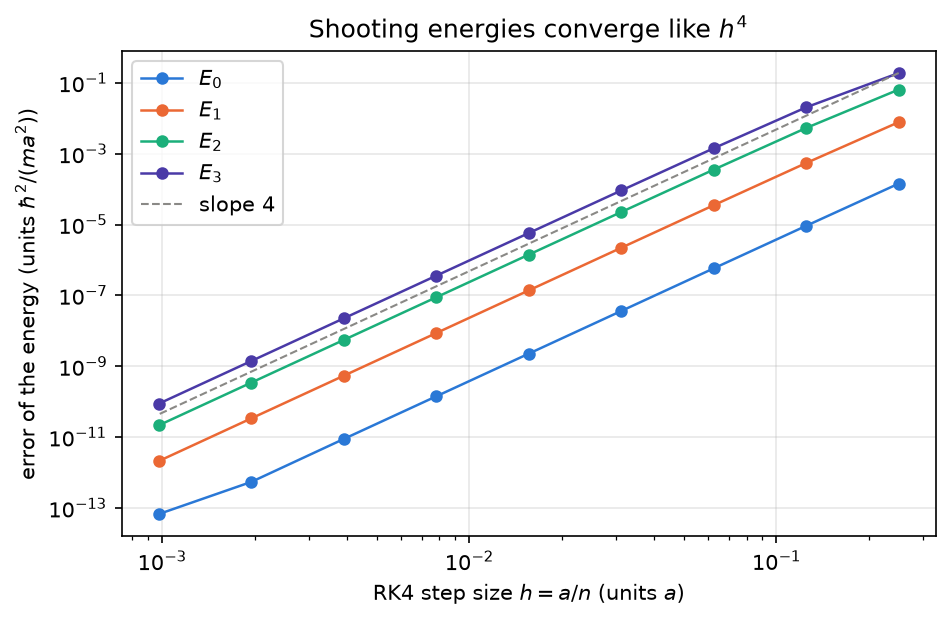

Figure 02b.8 saved as Revision/textbook/figures/02b_8_eigenvalue_convergence.png
RESULT measured orders of E_0 ... E_3 = 3.99, 3.98, 3.96, 3.92
PASS the energy errors fall with the order 4 (slopes between 3.8 and 4.3)
PASS with 1024 steps every energy is within 1e-9


In [11]:
N_STEPS = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
level_errors = np.array([np.abs(well_levels(n)[0] - exact) for n in N_STEPS])
h_values = A / np.array(N_STEPS, dtype=float)
fig, ax = plt.subplots()
slopes = []
for n in range(4):
    ax.loglog(h_values, level_errors[:, n], "o-", color=LEVEL_COLORS[n], ms=5,
              lw=1.2, label=f"$E_{n}$")
    fit = level_errors[:, n] > 1e-12  # leave out the rounding-limited points
    slope, _ = np.polyfit(np.log10(h_values[fit]), np.log10(level_errors[fit, n]), 1)
    slopes.append(slope)
guide = level_errors[0, 3] * (h_values / h_values[0]) ** 4
ax.loglog(h_values, guide, "--", color=GREY, lw=1.0, label="slope 4")
ax.set_xlabel("RK4 step size $h = a/n$ (units $a$)")
ax.set_ylabel("error of the energy (units $\\hbar^2/(m a^2)$)")
ax.set_title("Shooting energies converge like $h^4$")
ax.legend()
save_figure(fig, "eigenvalue_convergence",
            "The error of the four shooting energies of the finite well, "
            "$|E_n(\\mathrm{RK4}) - E_n(\\mathrm{exact})|$ in units of "
            "$\\hbar^2/(m a^2)$, against the RK4 step size $h = a/n$ for "
            "$n = 4$ to $1024$ steps, on logarithmic axes. The points follow lines "
            "of slope 4 (dashed guide): halving the step divides the error of "
            "an eigenvalue by 16, the order of RK4. Higher states (faster "
            "oscillation) have larger errors at the same step.")
report("measured orders of E_0 ... E_3", ", ".join(f"{s:.2f}" for s in slopes))
check(all(3.8 < s < 4.3 for s in slopes),
      "the energy errors fall with the order 4 (slopes between 3.8 and 4.3)")
check(np.all(level_errors[-1] < 1e-9), "with 1024 steps every energy is within 1e-9")

## 13. The last check

The last cell checks that all 8 figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [12]:
names = ["trial_solutions_string", "shooting_function_string",
         "bisection_vs_secant", "graphical_solution", "shooting_functions_well",
         "trial_solutions_well", "eigenfunctions", "eigenvalue_convergence"]
present = [output_file(f"{FIGURE_FOLDER}/02b_{k}_{name}.png").is_file()
           for k, name in enumerate(names, 1)]
check(all(present), f"all {len(names)} figure files of notebook 02b exist")
all_checks_passed()

PASS all 8 figure files of notebook 02b exist
ALL 16 CHECKS PASSED (notebook 02b)


## 14. What this notebook showed

- A boundary-value problem with an unknown number in it becomes a sequence of
  initial-value problems: shoot from one end, measure the mismatch at the other
  end, and find the zeros of the shooting function.
- For the string $u'' = -\lambda u$, $u(0) = u(1) = 0$, the RK4 shooting function
  equals $\sin\sqrt{\lambda}/\sqrt{\lambda}$ and its zeros are
  $\lambda_n = n^2\pi^2$. Bisection gains one binary digit per step (after 45
  steps the bracket is still $2.8 \times 10^{-13}$ wide); the secant rule
  reaches the rounding level in about 9 steps.
- The finite square well of depth 15 and half-width 1 has exactly four bound
  states, alternately even and odd, with $n$ nodes in the state $n$; shooting
  with RK4 and the parity conditions $u'(0) = 0$ or $u(0) = 0$ at the centre
  reproduces the exact energies of the transcendental equations (within
  $10^{-7}$ with 200 steps, $10^{-9}$ with 1024 steps), and the energy errors
  fall like $h^4$.
- Away from an eigenvalue the shot flies off to $\pm\infty$: only special
  energies give a solution that decays on both sides.
- The wave functions of different energies are orthogonal.